# Data Analysis and Visualization - Lab 02
**Name:** Muneeb Riaz  
**Roll No:** 24i-2565  
**Section:** DS-B

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [2]:
# Load and clean dataset
df = pd.read_csv('adult.csv', na_values='?')
df_clean = df.dropna().copy()

# Save cleaned dataset for submission
df_clean.to_csv('24i2565_DS-B_Lab02_cleaned.csv', index=False)
df_clean.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K
5,34,Private,216864,HS-grad,9,Divorced,Other-service,Unmarried,White,Female,0,3770,45,United-States,<=50K
6,38,Private,150601,10th,6,Separated,Adm-clerical,Unmarried,White,Male,0,3770,40,United-States,<=50K


### Task 1: Bar Chart

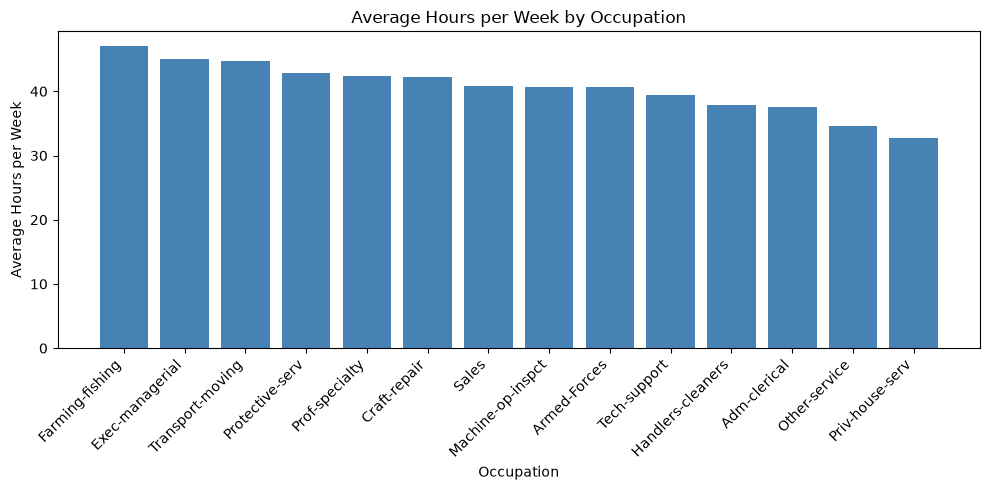

In [3]:
# Average hours worked per week by occupation
avg_hours = df_clean.groupby('occupation')['hours.per.week'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
plt.bar(avg_hours.index, avg_hours.values, color='steelblue')
plt.title('Average Hours per Week by Occupation')
plt.xlabel('Occupation')
plt.ylabel('Average Hours per Week')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Task 2: Count Plot

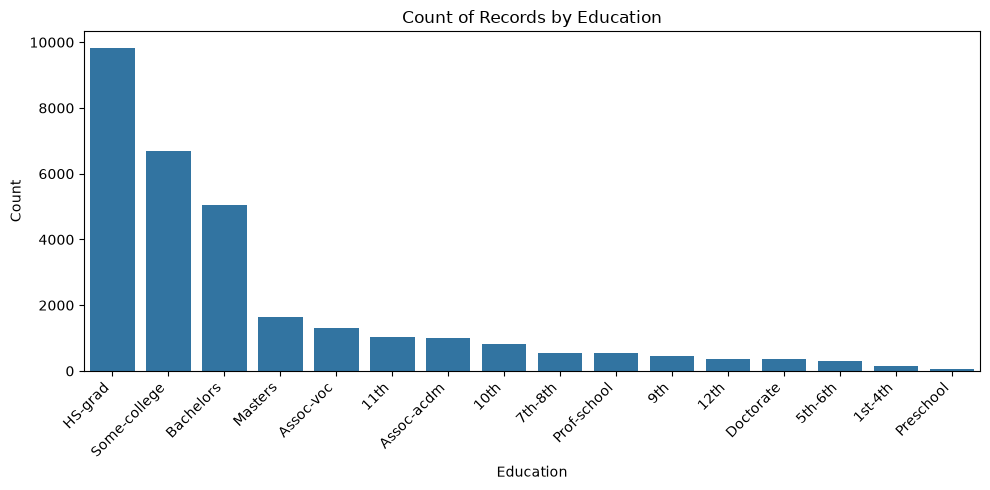

In [4]:
plt.figure(figsize=(10, 5))
order = df_clean['education'].value_counts().index
sns.countplot(data=df_clean, x='education', order=order)
plt.title('Count of Records by Education')
plt.xlabel('Education')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Most common category:** `HS-grad` is the most common category with 9,840 records.

### Task 3: Histogram

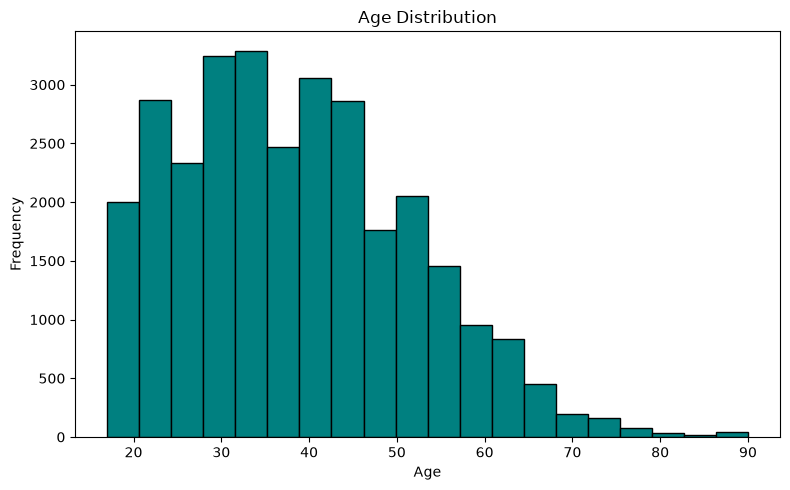

In [5]:
plt.figure(figsize=(8, 5))
plt.hist(df_clean['age'], bins=20, edgecolor='black', color='teal')
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

**Distribution Shape:** The distribution of age is skewed right.

### Task 4: Box Plot

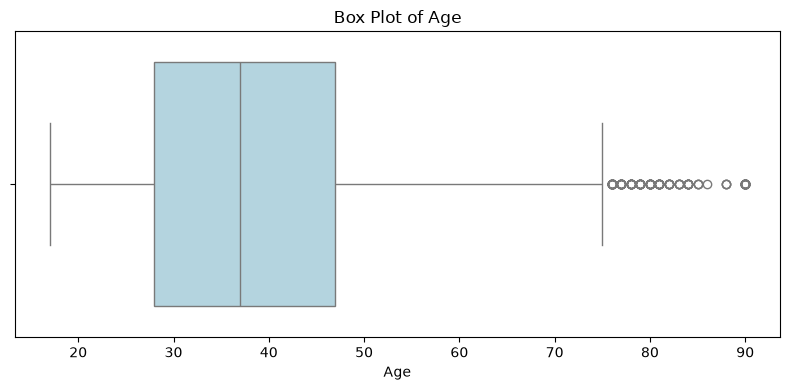

In [6]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=df_clean['age'], color='lightblue')
plt.title('Box Plot of Age')
plt.xlabel('Age')
plt.tight_layout()
plt.show()

**Visual Outliers:** By looking at the box plot, there are many outlier points visible past the right whisker (above age 75).

### Task 5: Outlier Detection (IQR)

In [7]:
Q1 = df_clean['age'].quantile(0.25)
Q3 = df_clean['age'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df_clean[(df_clean['age'] < lower) | (df_clean['age'] > upper)]

print(f"Q1: {Q1}, Q3: {Q3}, IQR: {IQR}")
print(f"Lower bound: {lower}, Upper bound: {upper}")
print(f"Number of IQR outliers: {len(outliers)}")

Q1: 28.0, Q3: 47.0, IQR: 19.0
Lower bound: -0.5, Upper bound: 75.5
Number of IQR outliers: 169


**Comparison:** IQR found 169 outliers. This matches the box plot where points appeared beyond the upper whisker, but IQR gives the exact count.

### Task 6: Outlier Detection (Z-score)

In [8]:
df_clean['zscore'] = stats.zscore(df_clean['age'])
outliers_z = df_clean[df_clean['zscore'].abs() > 3]

print(f"Number of Z-score outliers: {len(outliers_z)}")

Number of Z-score outliers: 120


**Explanation:** IQR flagged 169 outliers while Z-score flagged 120. They do not match because the age column is skewed right, which inflates the mean and standard deviation, making the Z-score range wider and missing some outliers.

### Task 7: Scatter Plot

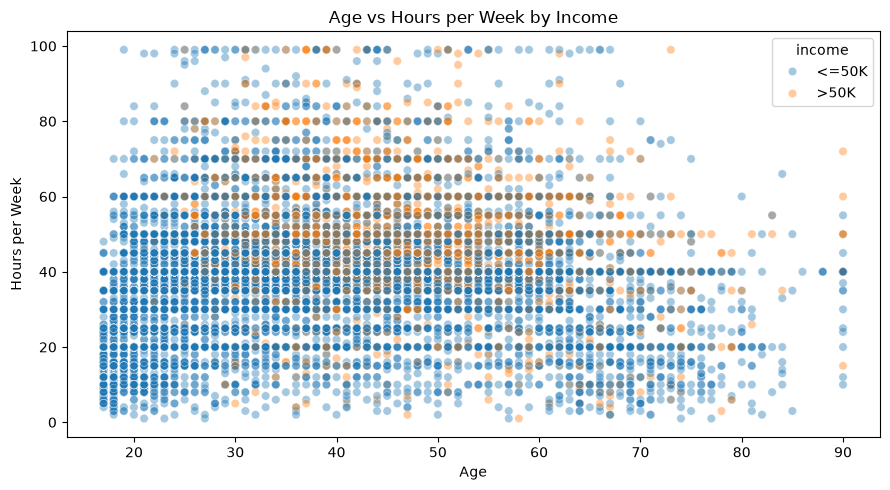

In [9]:
plt.figure(figsize=(9, 5))
sns.scatterplot(data=df_clean, x='age', y='hours.per.week', hue='income', alpha=0.4)
plt.title('Age vs Hours per Week by Income')
plt.xlabel('Age')
plt.ylabel('Hours per Week')
plt.tight_layout()
plt.show()

**Relationship:** There is a weak relationship between age and hours worked, with most people working around 40 hours per week across all ages.

### Task 8: Line and Area Chart

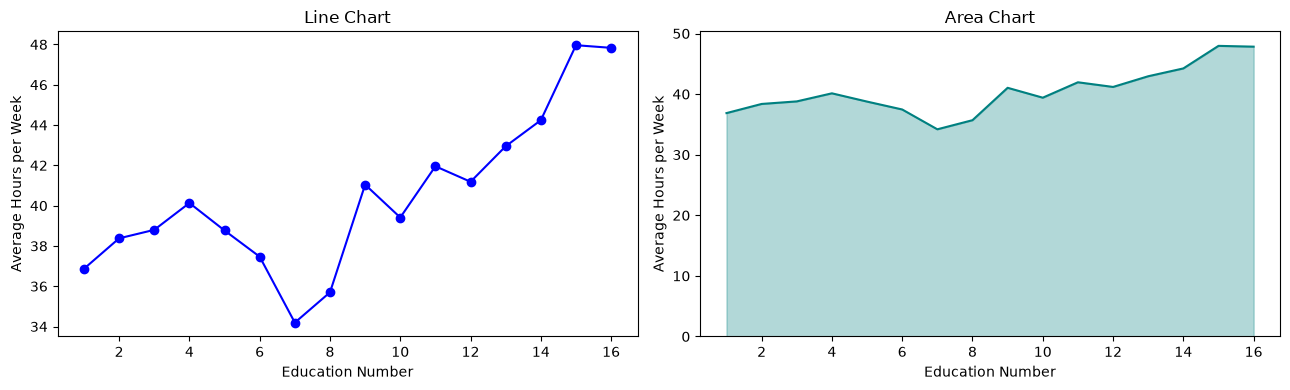

In [10]:
trend = df_clean.groupby('education.num')['hours.per.week'].mean().reset_index()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

# Line chart
ax1.plot(trend['education.num'], trend['hours.per.week'], marker='o', color='blue')
ax1.set_title('Line Chart')
ax1.set_xlabel('Education Number')
ax1.set_ylabel('Average Hours per Week')

# Area chart
ax2.plot(trend['education.num'], trend['hours.per.week'], color='teal')
ax2.fill_between(trend['education.num'], trend['hours.per.week'], color='teal', alpha=0.3)
ax2.set_title('Area Chart')
ax2.set_xlabel('Education Number')
ax2.set_ylabel('Average Hours per Week')
ax2.set_ylim(bottom=0)

plt.tight_layout()
plt.show()

**Comparison:** The line chart focuses on the trend between education levels, while the area chart shows the overall volume of hours worked.

### Task 9: Graphical Integrity Check

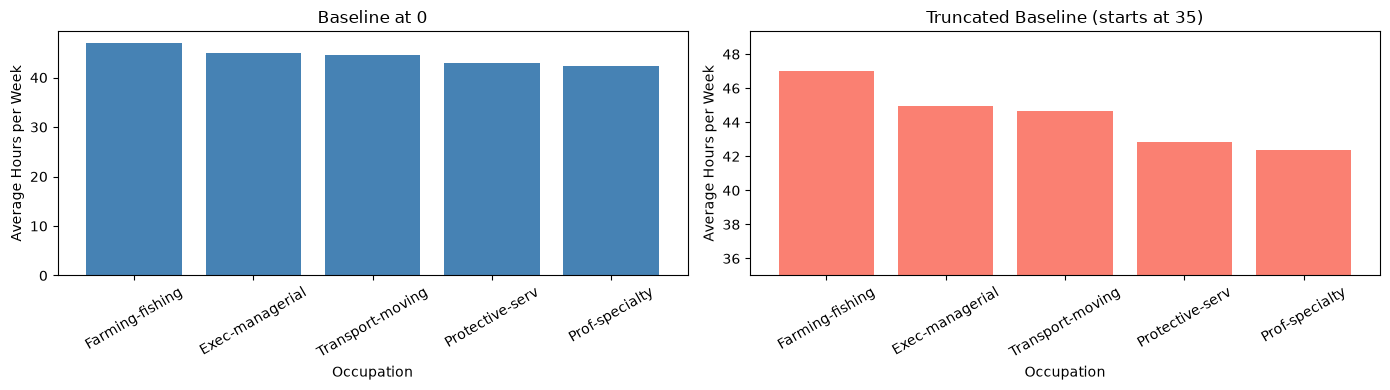

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

top_occ = avg_hours.head(5)

# Normal plot (starts at 0)
ax1.bar(top_occ.index, top_occ.values, color='steelblue')
ax1.set_title('Baseline at 0')
ax1.set_xlabel('Occupation')
ax1.set_ylabel('Average Hours per Week')
ax1.set_ylim(bottom=0)
ax1.tick_params(axis='x', rotation=30)

# Truncated plot (starts at 35)
ax2.bar(top_occ.index, top_occ.values, color='salmon')
ax2.set_title('Truncated Baseline (starts at 35)')
ax2.set_xlabel('Occupation')
ax2.set_ylabel('Average Hours per Week')
ax2.set_ylim(bottom=35)
ax2.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

**Integrity Check:** Truncating the y-axis to start at 35 makes small differences between occupations look huge. The plot starting at 0 shows that the actual difference in hours worked is small.